## Baseline return model (momentum only)

Implements the **baseline** block in [`docs/model_spec.md`](../../docs/model_spec.md):

- **Linear:** `forward_return_1d ~ momentum_1d` (+ intercept).
- **Classification:** `P(forward_return_1d < 0)` via **logit** with **momentum only** (same predictors as the linear baseline, plus constant).

**Evaluation:** 
- **HC1** and **cluster-robust** OLS
- logit + **`get_margeff(at="overall")`** + **ROC-AUC** (ranking quality for predicted downside probability)
- **walk-forward** with **rolling** train window 

**Sample:** 
- MAG7, project window from `msa.utils.vars`
- **`sentiment_label == "negative"`** 
- Article rows: same slice as **`04` / `05`** so the baseline is comparable to the interaction spec on the **same rows**.

Metric definitions: [`docs/metrics.md`](../../docs/metrics.md).


### Data loading


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import brier_score_loss, mean_squared_error, r2_score, roc_auc_score

from msa.utils.paths import get_joined_dataset
from msa.utils.vars import MAG7_TICKERS, WINDOW_END, WINDOW_START

warnings.filterwarnings("ignore", category=FutureWarning)

INPUT_PATH = get_joined_dataset()
df = pd.read_csv(INPUT_PATH, parse_dates=["date", "article_date", "price_date"])
print(f"Loaded {len(df):,} rows from {INPUT_PATH.name}")


Loaded 89,405 rows from gdelt_ohlcv_join.csv


### Filter to MAG7, window, negative headlines


In [2]:
df_filtered = df[
    (df["price_date"].dt.normalize() >= pd.Timestamp(WINDOW_START))
    & (df["price_date"].dt.normalize() <= pd.Timestamp(WINDOW_END))
].copy()
df_mag7 = df_filtered[df_filtered["ticker"].isin(MAG7_TICKERS)].copy()
df_mag7_neg = df_mag7[df_mag7["sentiment_label"] == "negative"].copy()
print(f"Negative MAG7 rows in window: {len(df_mag7_neg):,}")


Negative MAG7 rows in window: 11,145


### Build daily returns and merge (same as `04` / `05`)


In [3]:
returns_daily = (
    df_mag7.groupby(["price_date", "ticker"], as_index=False).agg(close=("next_close", "first"))
)
returns_daily["price_date"] = pd.to_datetime(returns_daily["price_date"]).dt.normalize()
returns_daily = returns_daily.sort_values(["ticker", "price_date"]).reset_index(drop=True)
returns_daily["return_1d"] = returns_daily.groupby("ticker")["close"].pct_change()
returns_daily["forward_return_1d"] = returns_daily.groupby("ticker")["return_1d"].shift(-1)

_mom = returns_daily[["price_date", "ticker", "return_1d"]].copy()
_mom["momentum_1d"] = _mom.groupby("ticker")["return_1d"].shift(1)

neg = df_mag7_neg.copy()
neg["price_date"] = pd.to_datetime(neg["price_date"]).dt.normalize()
merge_cols = ["price_date", "ticker", "forward_return_1d"]
panel = neg.merge(returns_daily[merge_cols], on=["price_date", "ticker"], how="left").merge(
    _mom[["price_date", "ticker", "momentum_1d"]],
    on=["price_date", "ticker"],
    how="left",
)

fit_df = panel.dropna(subset=["forward_return_1d", "momentum_1d", "price_date", "ticker"]).copy()
print(f"Rows with momentum + forward return: {len(fit_df):,}")


Rows with momentum + forward return: 11,007


### 1. In-sample OLS (baseline)

`forward_return_1d ~ momentum_1d`


In [4]:
y = fit_df["forward_return_1d"]
X = sm.add_constant(fit_df[["momentum_1d"]])

res_ols = sm.OLS(y, X).fit()
res_hc1 = sm.OLS(y, X).fit(cov_type="HC1")
print("=== OLS (nonrobust SE) ===")
print(res_ols.summary())
print("\n=== OLS HC1 ===")
print(res_hc1.summary())

g_date = pd.factorize(fit_df["price_date"])[0]
res_cl_d = sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": g_date})
res_cl_t = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": fit_df["ticker"].astype("category").cat.codes},
)
print("\n=== OLS cluster by price_date ===")
print(res_cl_d.summary())
print("\n=== OLS cluster by ticker ===")
print(res_cl_t.summary())


=== OLS (nonrobust SE) ===
                            OLS Regression Results                            
Dep. Variable:      forward_return_1d   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     48.76
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           3.06e-12
Time:                        19:45:52   Log-Likelihood:                 18066.
No. Observations:               11007   AIC:                        -3.613e+04
Df Residuals:                   11005   BIC:                        -3.611e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0050 

### 2. In-sample logit (downside probability)

Outcome: **1** if `forward_return_1d` is below zero. Single predictor: **momentum_1d**.


In [5]:
y_bin = (fit_df["forward_return_1d"] < 0).astype(int)
logit_res = sm.Logit(y_bin, X).fit(disp=False, maxiter=500)
print(logit_res.summary())
print(logit_res.get_margeff(at="overall").summary())

# In-sample ROC-AUC (same metric family as models/00-model-selection-start.ipynb classification runs)
p_in = logit_res.predict(X)
try:
    auc_in = roc_auc_score(y_bin, p_in)
    print(f"\nIn-sample ROC-AUC (logit, momentum only): {auc_in:.4f}")
except ValueError as e:
    print("ROC-AUC skipped (need both classes):", e)


                           Logit Regression Results                           
Dep. Variable:      forward_return_1d   No. Observations:                11007
Model:                          Logit   Df Residuals:                    11005
Method:                           MLE   Df Model:                            1
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                0.005453
Time:                        19:45:52   Log-Likelihood:                -7520.6
converged:                       True   LL-Null:                       -7561.8
Covariance Type:            nonrobust   LLR p-value:                 1.073e-19
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.2277      0.019    -11.819      0.000      -0.266      -0.190
momentum_1d     3.6868      0.412      8.947      0.000       2.879       4.494
        Logit Marginal Effects       
Dep. Varia

### 3. Walk-forward (rolling train window)

Same **time-ordered** design as **`05`**, but **only** `momentum_1d` in the model (no sentiment, no per-fold quantile). 
- See **Time-based validation** in `metrics.md`.


In [6]:
ROLLING_TRAIN_DAYS = 126
MIN_TRAIN_ROWS = 800
USE_EXPANDING_WINDOW = False

wf_panel = fit_df.copy()
unique_dates = sorted(wf_panel["price_date"].unique())
FEATURES = ["momentum_1d"]

rows = []
for i, test_date in enumerate(unique_dates):
    if USE_EXPANDING_WINDOW:
        train_dates = unique_dates[:i]
    else:
        if i < ROLLING_TRAIN_DAYS:
            continue
        train_dates = unique_dates[i - ROLLING_TRAIN_DAYS : i]
    if not train_dates:
        continue

    train = wf_panel[wf_panel["price_date"].isin(train_dates)].dropna(subset=FEATURES + ["forward_return_1d"])
    test = wf_panel[wf_panel["price_date"] == test_date].dropna(subset=FEATURES + ["forward_return_1d"])
    if len(train) < MIN_TRAIN_ROWS or len(test) < 1:
        continue

    X_tr = sm.add_constant(train[FEATURES])
    y_tr = train["forward_return_1d"]
    X_te = sm.add_constant(test[FEATURES])
    y_te = test["forward_return_1d"]

    try:
        ols = sm.OLS(y_tr, X_tr).fit()
        pred = ols.predict(X_te)
    except (np.linalg.LinAlgError, ValueError):
        continue

    pred_arr = np.asarray(pred, dtype=float).ravel()
    y_arr = y_te.to_numpy(dtype=float).ravel()
    rmse = float(np.sqrt(mean_squared_error(y_arr, pred_arr)))
    r2_oos = (
        float(r2_score(y_arr, pred_arr))
        if len(y_arr) >= 2 and np.nanvar(y_arr) > 1e-16
        else np.nan
    )
    nz = y_arr != 0
    sign_acc = (
        float(np.mean(np.sign(pred_arr[nz]) == np.sign(y_arr[nz])))
        if nz.sum() > 0
        else np.nan
    )

    y_bin_tr = (y_tr < 0).astype(int)
    y_bin_te = (y_te < 0).astype(int)
    brier = np.nan
    mean_p_down = np.nan
    auc_oos = np.nan
    if y_bin_tr.nunique() > 1:
        try:
            lr = sm.Logit(y_bin_tr, X_tr).fit(disp=False, maxiter=500)
            p_down = lr.predict(X_te)
            p_arr = np.asarray(p_down, dtype=float).ravel()
            brier = float(brier_score_loss(y_bin_te.astype(int), p_arr))
            mean_p_down = float(np.mean(p_arr))
            if y_bin_te.nunique() > 1:
                auc_oos = float(roc_auc_score(y_bin_te.astype(int), p_arr))
        except Exception:
            pass

    rows.append(
        {
            "test_date": test_date,
            "n_train": len(train),
            "n_test": len(test),
            "ols_r2_oos": r2_oos,
            "ols_rmse_oos": rmse,
            "sign_accuracy": sign_acc,
            "logit_brier_oos": brier,
            "logit_roc_auc_oos": auc_oos,
            "coef_mom_train": float(ols.params.get("momentum_1d", np.nan)),
            "mean_pred_return": float(np.mean(pred_arr)),
            "mean_actual_return": float(np.mean(y_arr)),
            "actual_down_rate": float(y_bin_te.mean()),
            "mean_pred_p_down": mean_p_down,
        }
    )

wf_results = pd.DataFrame(rows).sort_values("test_date")
print(f"Walk-forward folds: {len(wf_results)} (rolling={ROLLING_TRAIN_DAYS}d)")
if len(wf_results):
    print(wf_results.describe().to_string())


Walk-forward folds: 159 (rolling=126d)
                           test_date      n_train      n_test   ols_r2_oos  ols_rmse_oos  sign_accuracy  logit_brier_oos  logit_roc_auc_oos  coef_mom_train  mean_pred_return  mean_actual_return  actual_down_rate  mean_pred_p_down
count                            159   159.000000  159.000000   159.000000    159.000000     159.000000       159.000000         110.000000      159.000000        159.000000          159.000000        159.000000        159.000000
mean   2025-06-27 16:45:16.981132032  3200.150943   44.578616   -33.074179      0.031975       0.539159         0.248677           0.512512       -0.075942          0.005638            0.002180          0.463157          0.433473
min              2024-10-09 00:00:00  2504.000000    2.000000 -4387.217929      0.002643       0.000000         0.092049           0.000000       -0.258417         -0.026326           -0.097640          0.000000          0.226818
25%              2025-02-19 12:00:00  295

### 4. Walk-forward diagnostics (plots)


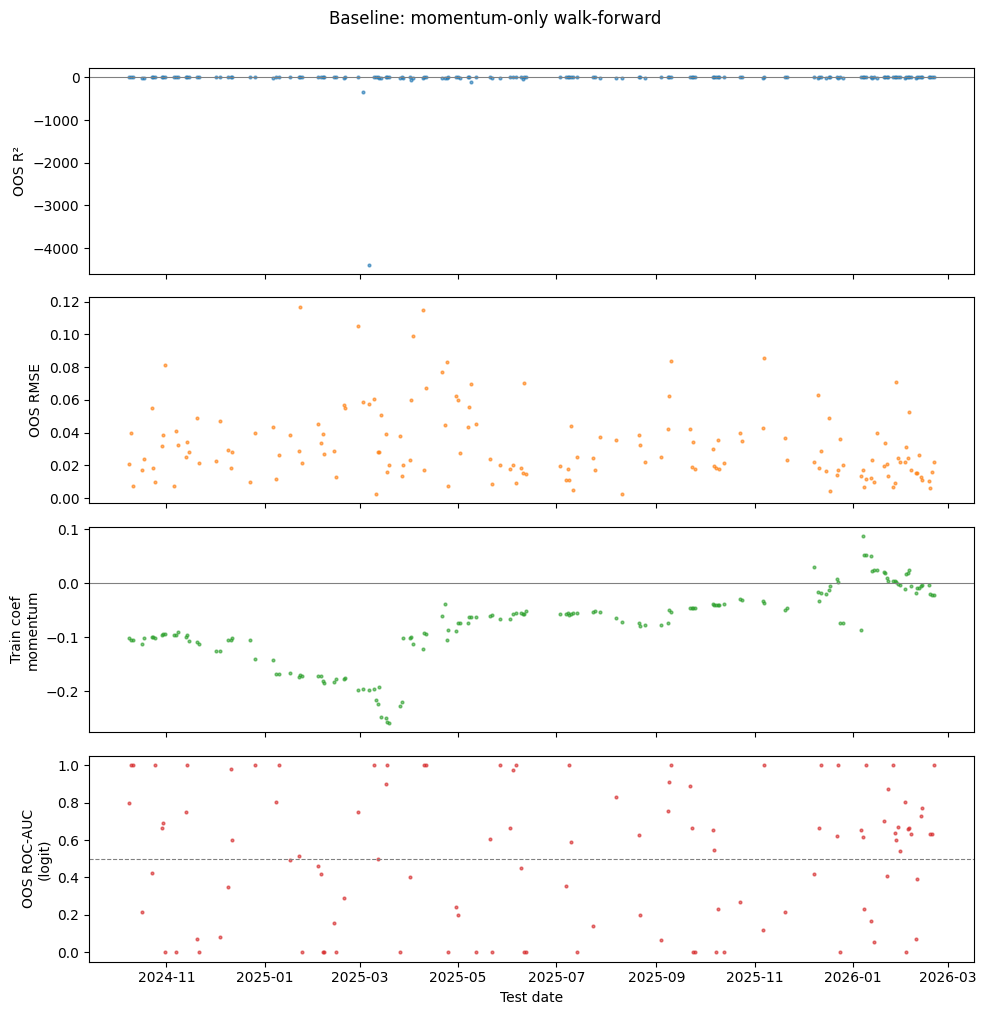

In [7]:
if wf_results.empty:
    print("No walk-forward rows.")
else:
    fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
    axes[0].plot(wf_results["test_date"], wf_results["ols_r2_oos"], ".", alpha=0.6, ms=4)
    axes[0].axhline(0, color="gray", lw=0.8)
    axes[0].set_ylabel("OOS R²")
    axes[1].plot(wf_results["test_date"], wf_results["ols_rmse_oos"], ".", alpha=0.6, ms=4, color="C1")
    axes[1].set_ylabel("OOS RMSE")
    axes[2].plot(wf_results["test_date"], wf_results["coef_mom_train"], ".", alpha=0.6, ms=4, color="C2")
    axes[2].axhline(0, color="gray", lw=0.8)
    axes[2].set_ylabel("Train coef\nmomentum")
    axes[3].plot(wf_results["test_date"], wf_results["logit_roc_auc_oos"], ".", alpha=0.6, ms=4, color="C3")
    axes[3].axhline(0.5, color="gray", lw=0.8, ls="--")
    axes[3].set_ylabel("OOS ROC-AUC\n(logit)")
    axes[3].set_xlabel("Test date")
    plt.suptitle("Baseline: momentum-only walk-forward", y=1.01)
    plt.tight_layout()
    plt.show()


### Findings 

- The momentum signal exhibits statistical significance under naive standard errors
- This significance **disappears** when using **cluster-robust standard errors**
    - This suggests that the effect is driven by cross-sectional/temporal dependence
- The model explains essentially none of the variation in returns ($R^2$ $\approx$ 0.004) $\rightarrow$ **neglible** predictive power
- In classification, model achieves **ROC-AUC $\approx$ 0.51** (marginally better than a coin-toss)
- Walk-forward validation reveals:
    - Consistently negative out-of-sample $R^2$
    - High instability in coefficient estimates
    - No consistent predictive signal over time

### Summary
> Overall, the momentum-only baseline demonstrates **weak, unstable and non-robust** predictive power for short-term returns

### Next Steps:
- Proceed with Interaction model (include regime-based sentiment modifier) to see whether performance improves